In [8]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from pyscf import ao2mo, gto, scf, fci, lo
import matplotlib.pyplot as plt

from libdet import Hamiltonian
from detnqs.model import Backflow
from detnqs.vstate import MCState
from detnqs.sampler import MCSampler
from detnqs.driver import VMC
from detnqs.optimizer import adamsr
from detnqs import utils

utils.batch.configure(chunk=8192)
utils.precision.configure("single")
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_log_compiles", False)

In [9]:
mol = gto.M(
    atom="; ".join([f"H 0 0 {i * 2.00}" for i in range(10)]),
    basis="sto-6g",
    unit="Angstrom",
    verbose=0,
)
mf = scf.RHF(mol).run()
norb = mf.mo_coeff.shape[1]
n_alpha, n_beta = mol.nelec

# Orthonormalized Atomic Orbitals (OAOs)
C = lo.orth.orth_ao(mol, 'lowdin')
h1e = C.T @ mf.get_hcore() @ C
eri = ao2mo.restore(8, ao2mo.kernel(mol, C), mol.nao_nr())
h1e[abs(h1e) < 1e-6] = eri[abs(eri) < 1e-6] = 0.0
mo_coeff = np.linalg.solve(C, mf.mo_coeff)

ref_mat = np.zeros((n_alpha + n_beta, 2 * norb))
ref_mat[:n_alpha, :norb] = mo_coeff[:, :n_alpha].T
ref_mat[n_alpha:, norb:] = mo_coeff[:, :n_beta].T

ham = Hamiltonian.rhf(h1e, eri, ecore=mol.energy_nuc())

# e_fci = -7.66652801326695

solver = fci.direct_spin0.FCI(mol)
e_fci, ci = solver.kernel(h1e, eri, norb, mol.nelec, ecore=mol.energy_nuc())
s2, mult = fci.spin_op.spin_square(ci, norb, mol.nelec)

print(f"SCF energy : {mf.e_tot:.12f}")
print(f"FCI energy : {e_fci:.12f}")
print(f"S^2  : {s2:.6f}")

SCF energy : -3.999817969532
FCI energy : -4.790991828654
S^2  : 0.000000


In [12]:
model = Backflow(norb=norb, n_alpha=n_alpha, n_beta=n_beta, hidden=(64,), ref_mat=jnp.array(ref_mat))

sampler = MCSampler(
    n_samples=1024,
    n_chains=1024,
    thermal_steps=1024,
    alpha="adaptive",
    proposal="ham",
    blur=0.5,
    blur_kernel="ham",
)

state = MCState.init(
    model=model,
    hamiltonian=ham,
    sampler=sampler,
    n_alpha=n_alpha,
    n_beta=n_beta,
    init_method="random",
    key=jax.random.key(0),
)

optimizer = optax.chain(
    adamsr(shift=1e-2),
    optax.scale(-5e-2)
)

steps = 1000

-----------------------------------------------------------------------
 Step          Energy      |E-E0|        Var     Acc     ESS    SR cond
-----------------------------------------------------------------------
    0     -4.02790833    7.63e-01   2.91e-01   0.785   0.510   1.59e+03
   10     -4.38742352    4.04e-01   1.42e-01   0.697   0.377   9.60e+02
   20     -4.62567234    1.65e-01   7.36e-02   0.584   0.248   9.35e+02
   30     -4.72475576    6.62e-02   2.95e-02   0.479   0.229   2.17e+03
   40     -4.76341581    2.76e-02   1.31e-02   0.421   0.220   5.33e+03
   50     -4.77548933    1.55e-02   5.09e-03   0.352   0.273   2.95e+03
   60     -4.78325701    7.73e-03   2.11e-03   0.307   0.296   1.58e+03
   70     -4.78452635    6.47e-03   1.41e-03   0.254   0.332   2.03e+03
   80     -4.78462410    6.37e-03   1.07e-03   0.226   0.363   3.53e+03
   90     -4.78741121    3.58e-03   6.87e-04   0.252   0.363   1.21e+03
  100     -4.78745174    3.54e-03   6.28e-04   0.235   0.357   3

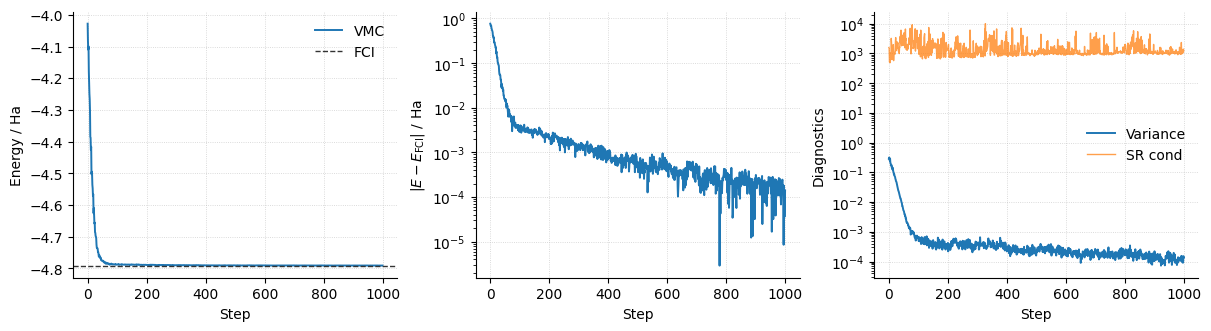

In [13]:
METRICS = {
    "step": ("Step", "5d"),
    "energy": ("Energy", "14.8f"),
    "error": ("|E-E0|", "10.2e"),
    "variance": ("Var", "9.2e"),
    "accept": ("Acc", "6.3f"),
    "ess_frac": ("ESS", "6.3f"),
    "sr_cond": ("SR cond", "9.2e"),
}

width = {k: int(fmt[:-1].split(".")[0]) for k, (_, fmt) in METRICS.items()}

header = "  ".join(f"{label:>{width[k]}}" for k, (label, _) in METRICS.items())
line = "-" * len(header)

print(line, header, line, sep="\n")

vmc = VMC.init(state, optimizer)
history = []
total_times = {}

for step in range(steps):
    stats = vmc.step()
    stats["error"] = abs(float(stats["energy"]) - e_fci)
    history.append(dict(stats))

    for k, v in stats.items():
        if k.startswith("time_"):
            name = k.removeprefix("time_")
            total_times[name] = total_times.get(name, 0.0) + float(v)

    if step % 10 == 0 or step == steps - 1:
        row = "  ".join(
            f"{int(stats.get(k, 0)):{fmt}}"
            if fmt.endswith("d")
            else f"{float(stats.get(k, 0.0)):{fmt}}"
            for k, (_, fmt) in METRICS.items()
        )
        print(row)

print(line)

if total_times:
    items = [(k, v) for k, v in total_times.items() if k != "total"]
    items = sorted(items, key=lambda kv: kv[1], reverse=True)
    print("Time:", "  ".join(f"{k}={v:.2f}s" for k, v in items))
    print(line)

hist = {k: np.asarray([s.get(k, np.nan) for s in history]) for k in METRICS}
x = hist["step"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), constrained_layout=True)

axes[0].plot(x, hist["energy"], lw=1.4, label="VMC")
axes[0].axhline(e_fci, ls="--", lw=1.0, c="0.2", label="FCI")
axes[0].set(xlabel="Step", ylabel="Energy / Ha")
axes[0].legend(frameon=False)

axes[1].semilogy(x, np.maximum(hist["error"], 1e-16), lw=1.4)
axes[1].set(xlabel="Step", ylabel=r"$|E-E_\mathrm{FCI}|$ / Ha")

axes[2].semilogy(x, np.maximum(hist["variance"], 1e-16), lw=1.4, label="Variance")
if "sr_cond" in hist:
    axes[2].semilogy(x, hist["sr_cond"], lw=1.0, alpha=0.75, label="SR cond")
axes[2].set(xlabel="Step", ylabel="Diagnostics")
axes[2].legend(frameon=False)

for ax in axes:
    ax.grid(True, ls=":", lw=0.6, alpha=0.6)
    ax.spines[["top", "right"]].set_visible(False)

plt.show()